[dataset](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records) from UCI repo

In [290]:
import pandas as pd
import numpy as np
from scipy.io import arff
import warnings
warnings.filterwarnings(action='ignore')
# 데이터 전처리
from sklearn.model_selection import train_test_split

# 모델 패키지
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 모델 평가
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rc('font', family='applegothic')

In [320]:
cols = ["time", "Rad Flow",
"Fpv Close",
"Fpv Open",
"High",
"Bypass",
"Bpv Close",
"Bpv Open", "label"]
data = pd.read_csv("/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/statlog+shuttle/shuttle.trn.csv", sep='\s', )

In [ ]:
# arff dataset load
file_path = '/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/bank-additional-ful-nominal.arff'

try:
    data, meta_data = arff.loadarff(file_path)
    data = pd.DataFrame(data)
    for col in data.select_dtypes(['object']).columns: # 2진수 decode 필수
        data[col] = data[col].str.decode('utf-8')

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(e)

In [316]:
print("data 갯수 :\t",len(data))
print("feature 갯수 :\t", len(data.columns))
data.head()

data 갯수 :	 43500
feature 갯수 :	 10


,0,1,2,3,4,5,6,7,8,9
0,50,21,77,0,28,0,27,48,22,2
1,55,0,92,0,0,26,36,92,56,4
2,53,0,82,0,52,-5,29,30,2,1
3,37,0,76,0,28,18,40,48,8,1
4,37,0,79,0,34,-26,43,46,2,1


In [306]:
data.describe()

,at_least_1_teacher_referred_donor=t,fully_funded=t,at_least_1_green_donation=0,great_chat=t,three_or_more_non_teacher_referred_donors=0,one_non_teacher_referred_donor_giving_100_plus=t,donation_from_thoughtful_donor=t,great_messages_proportion,teacher_referred_count,non_teacher_referred_count,class
count,619326.000000,619326.000000,619326.000000,619326.000000,619326.000000,619326.000000,619326.000000,619326.000000,619326.000000,619326.000000,619326.000000
mean,0.237480,0.695406,0.278581,0.302216,0.481114,0.719735,0.013213,0.529271,0.005148,0.014346,0.059274
std,0.391769,0.460236,0.412724,0.459219,0.459992,0.413487,0.105125,0.300852,0.013584,0.017167,0.236137
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.719735,0.000000,0.420000,0.000000,0.006579,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.481114,1.000000,0.000000,0.529271,0.000000,0.009868,0.000000
75%,0.237480,1.000000,0.278581,1.000000,1.000000,1.000000,0.000000,0.660000,0.005148,0.014346,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# for heart disease data
print(data['DEATH_EVENT'].value_counts())

# make data unbalanced.
data_major = data[data['DEATH_EVENT']==0]
data_minor = data[data['DEATH_EVENT']==1]
print(len(data_major))
data_minor_handle = data_minor.sample(frac=0.3, random_state=42)

print(len(data_minor_handle))
data_modi= pd.concat([data_major, data_minor_handle], ignore_index=True)
data_modi['DEATH_EVENT'].value_counts()

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64
203
29


DEATH_EVENT
0    203
1     29
Name: count, dtype: int64

<Axes: xlabel='platelets', ylabel='creatinine_phosphokinase'>

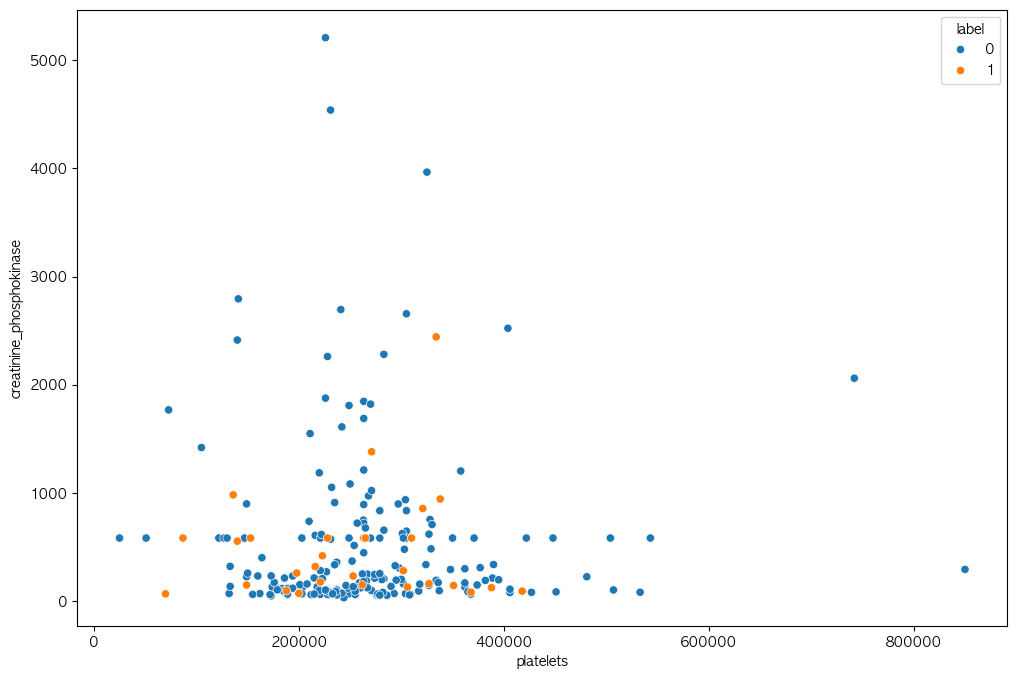

In [242]:
data_modi = data_modi.rename(columns={'DEATH_EVENT' : 'label'})
plt.figure(figsize=(12,8))
sns.scatterplot(x='platelets', y='creatinine_phosphokinase', hue='label', data=data_modi)

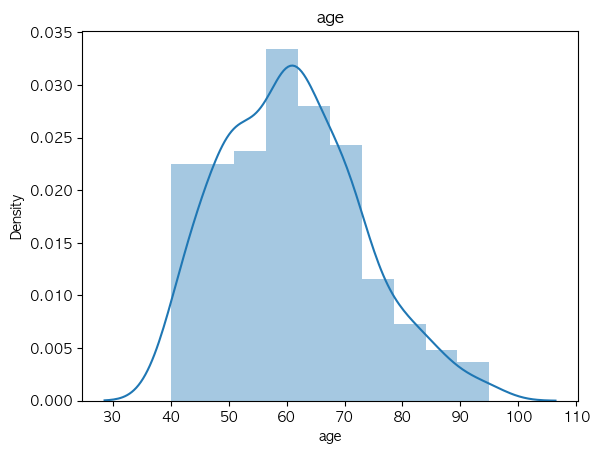

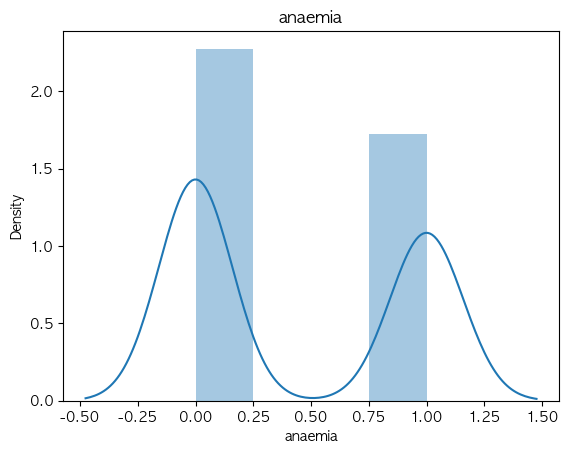

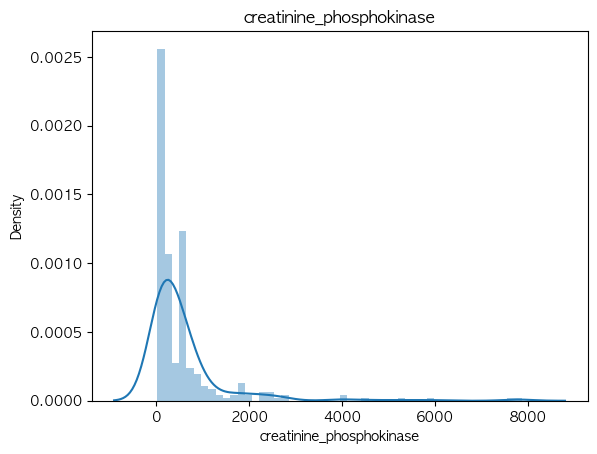

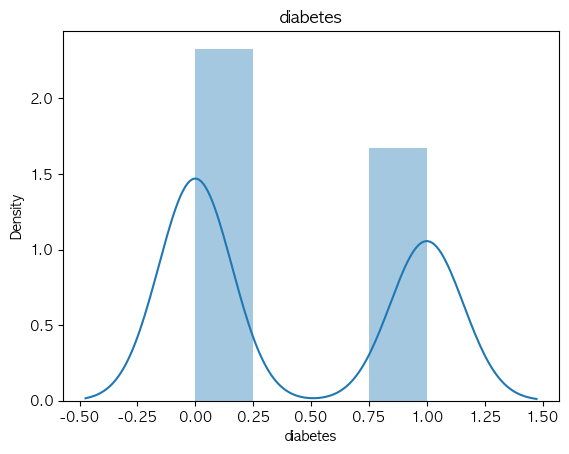

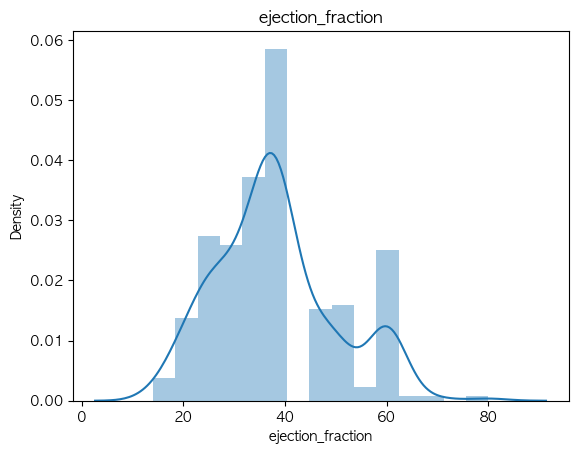

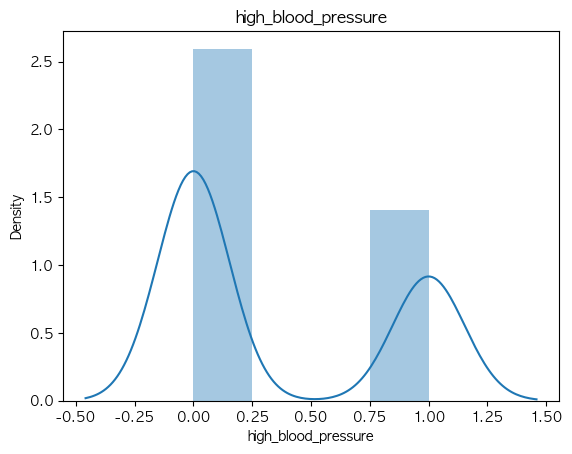

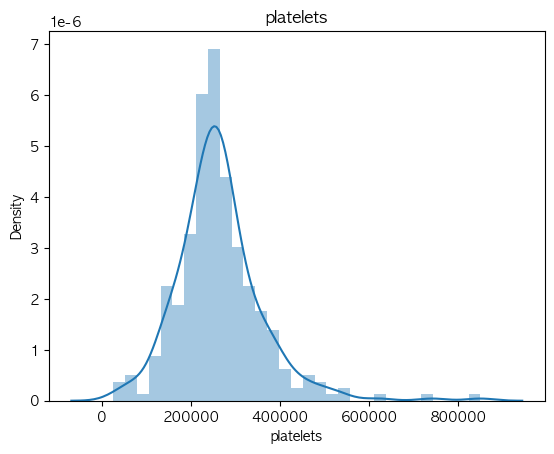

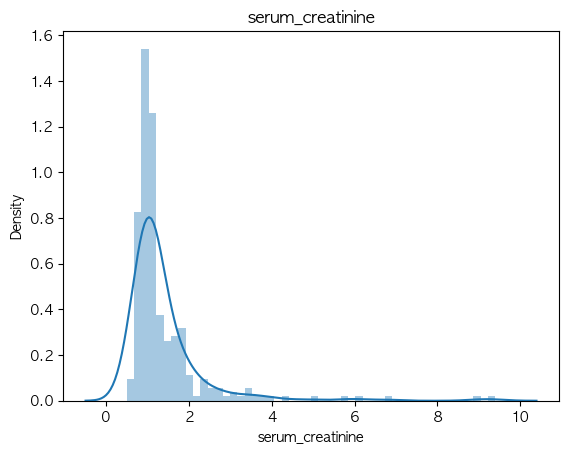

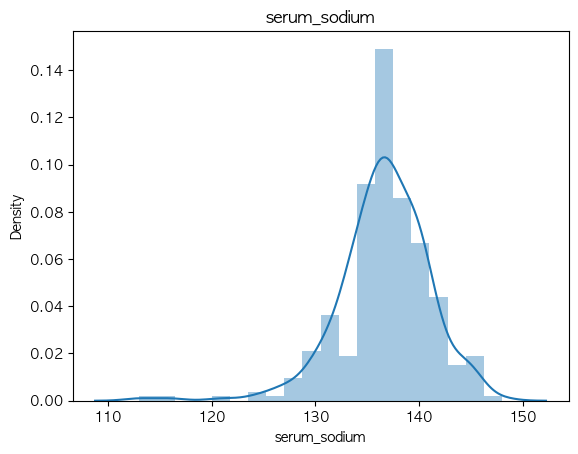

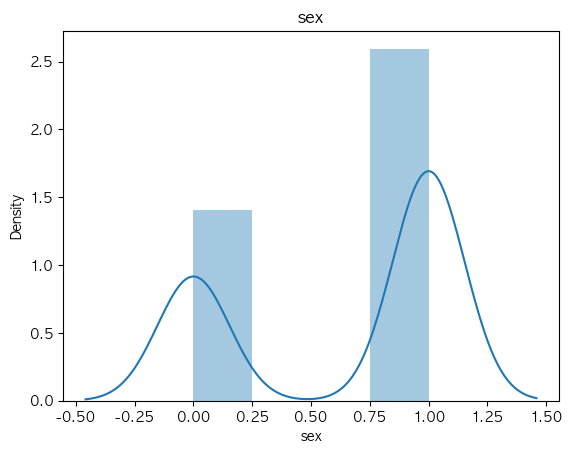

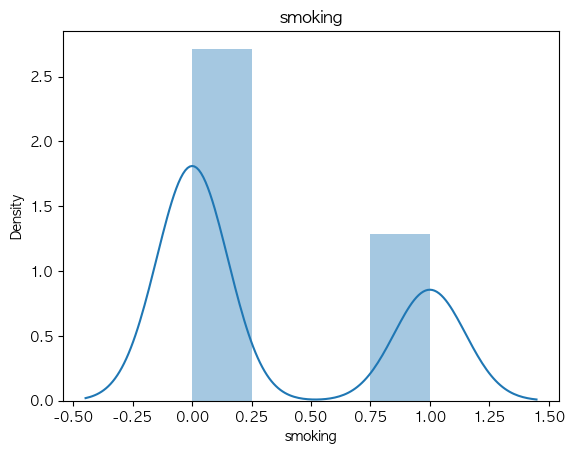

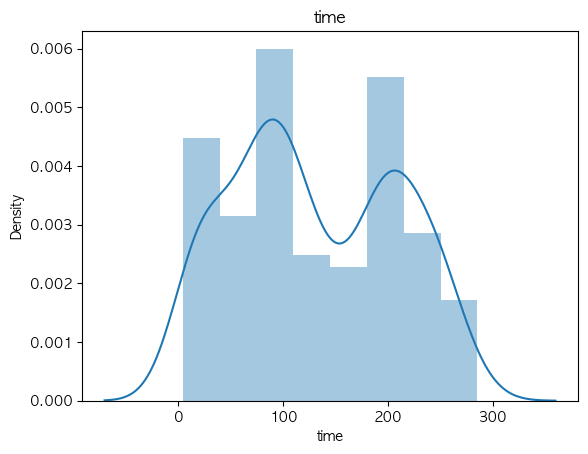

KeyError: 'label'

In [243]:
for col in data_modi:
    sns.distplot(data.loc[data[col].notnull(), col])
    plt.title(col)
    plt.show()

In [ ]:
target = data_modi['label']
target.count()

232

label
0    203
1     29
Name: count, dtype: int64


<Axes: title={'center': 'class distribution'}, xlabel='count', ylabel='label'>

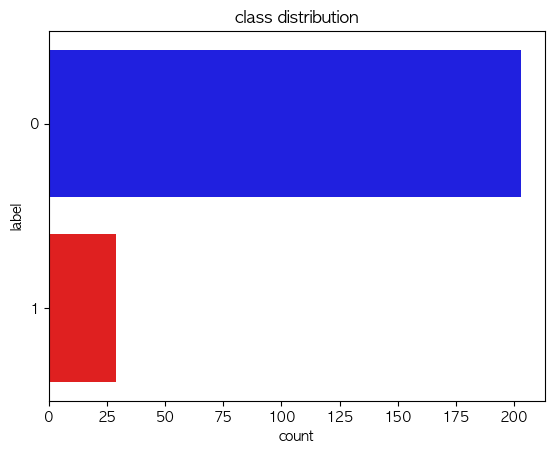

In [248]:
print(target.value_counts())
plt.title("class distribution")
sns.countplot(y=data_modi['label'], data=data_modi, palette=['blue','red'])

In [250]:
x = data_modi[data_modi.columns.difference(['label'])]
y = data_modi['label']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.1, random_state=42)

In [251]:
y_test.value_counts()

label
0    20
1     4
Name: count, dtype: int64

In [256]:
# 명목형 변수 : anaemia diabetes high_blood_pressure serum_creatinine sex smoking - 0 or 1
# time : follow-up perioud
x

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,49.0,1,80,0,30,1,427000.0,1.0,138,0,0,12
1,65.0,1,52,0,25,1,276000.0,1.3,137,0,0,16
2,53.0,0,63,1,60,0,368000.0,0.8,135,1,0,22
3,50.0,1,159,1,30,0,302000.0,1.2,138,0,0,29
4,60.0,0,2656,1,30,0,305000.0,2.3,137,1,0,30
...,...,...,...,...,...,...,...,...,...,...,...,...
227,77.0,1,418,0,45,0,223000.0,1.8,145,1,0,180
228,80.0,1,123,0,35,1,388000.0,9.4,133,1,1,10
229,50.0,0,582,1,38,0,310000.0,1.9,135,1,1,35
230,62.0,0,231,0,25,1,253000.0,0.9,140,1,1,10


In [257]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_scaled = sc.fit_transform(x)

x_scaled = pd.DataFrame(x_scaled, columns=x.columns)
x_scaled

x_train_sc, x_test_sc, y_train, y_test = train_test_split(x,y, test_size=0.1, random_state=42)

# PCA
- std 가 큰 변수에 영향을 받는다 → scaling

In [258]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
result = pca.fit_transform(x_scaled)

print(pca.explained_variance_ratio_)
result =pd.DataFrame(result, columns=['feature1', 'feature2'])

[0.14165224 0.13442801]


In [259]:
result['label'] = y
result

,feature1,feature2,label
0,-1.759616,-1.427005,0
1,-1.049219,-2.345214,0
2,-0.790371,0.074171,0
3,-1.542583,-0.695890,0
4,0.955233,0.215285,0
...,...,...,...
227,0.241151,-0.757179,1
228,3.557819,-6.653404,1
229,1.383603,0.165706,1
230,1.578286,-0.765595,1


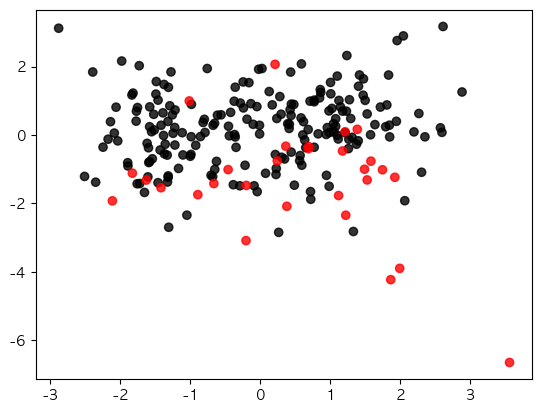

In [260]:
color_map = {0:'black', 1:'red'}
colors = result['label'].map(color_map)
plt.scatter(x=result['feature1'], y=result['feature2'], c = colors, alpha=0.8)

In [261]:
# 재구성 기반은 이상치는 다시 복구가 안될 것이다 라는 전제
x_proj = pca.inverse_transform(pca.fit_transform(x_scaled))
recon_error = ( (x_scaled - x_proj) **2 ).sum(axis=1)
thre = np.percentile(recon_error.sort_values(ascending=False), 90)

pred_pca = (recon_error >= thre).astype(int)
pred_pca

print(classification_report(y, pred_pca, digits=3))

              precision    recall  f1-score   support

           0      0.875     0.897     0.886       203
           1      0.125     0.103     0.113        29

    accuracy                          0.797       232
   macro avg      0.500     0.500     0.499       232
weighted avg      0.781     0.797     0.789       232



# KNN

In [262]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', metric='minkowski')
knn.fit(x_train_sc, y_train)

KNeighborsClassifier(weights='distance')

In [263]:
knn_pred_train = knn.predict(x_train_sc)
knn_pred_test = knn.predict(x_test_sc)

print(metrics.accuracy_score(y_train, knn_pred_train))
print(metrics.accuracy_score(y_test, knn_pred_test))

1.0
0.75


[[18  2]
 [ 4  0]]


<Axes: >

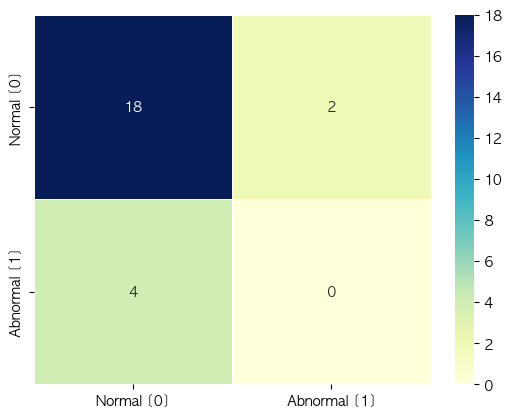

In [264]:
cm = confusion_matrix(y_test, knn_pred_test)

# col : 모델 예측 
# raw : 실제
print(cm)

sns.heatmap(pd.DataFrame(cm, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# KMeans

In [266]:
ssd = []
for num in range(2, 11):
    km = KMeans(n_clusters=num, init='k-means++', random_state=42, n_init=10)
    km.fit(x_train_sc)
    ssd.append(km.inertia_)

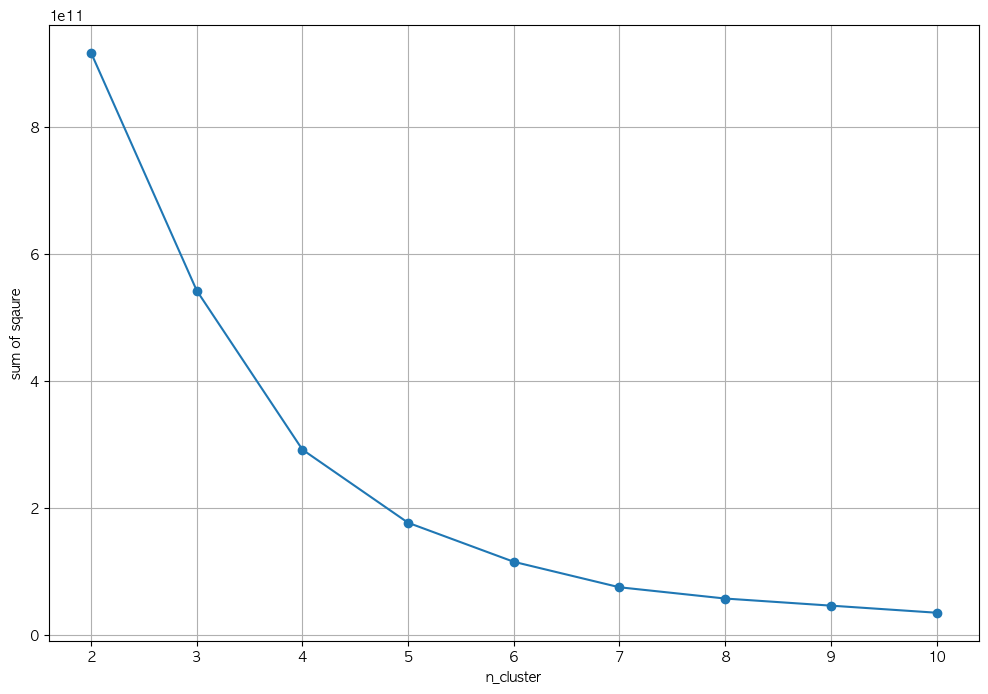

In [268]:
plt.figure(figsize=(12,8))
plt.plot(range(2,11), ssd, marker='o')
plt.xlabel('n_cluster')
plt.ylabel('sum of sqaure')
plt.xticks(range(2,11))
plt.grid()
plt.show()

In [270]:
km = KMeans(n_clusters=5)
model = km.fit(x_train_sc)

In [ ]:
def distance_from_center(input_data:pd.DataFrame, predict:pd.DataFrame, y):
    center = model.cluster_centers_[predict]
    dist = ((center-input_data)**2).sum(axis=1) # center 와 input_data 빼고 제곱하고 
    return np.round(dist, 3)

dist = distance_from_center(x_test, model.predict(x_test), y_test)

x_test['dist'] = dist

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- dist


In [ ]:
# 24개 test data 에 대해 3개 이상치 데이터로 선정
outlier_idx = list(x_test.sort_values('dist',ascending=False).head(10).index)